In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [125]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
    #setParametersALN(aln)
                    
def setParametersALN(model):
    model.params.rates_exc_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.rates_inh_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mufe_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.mufi_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.IA_init = np.array( [[0. * 200. * 0.5 ]] )  # pA
    model.params.seem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.seim_init = np.array( [[0. * 0.5 * 0.5 ]] )   
    model.params.seev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.seiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siim_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mue_ou = np.array( [[0. * 0.4]] ) #* np.ones((model.params.N,))
    model.params.mui_ou = np.array( [[0. * 0.3]] ) #* np.ones((model.params.N,))           

In [4]:
tol = 1e-32

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

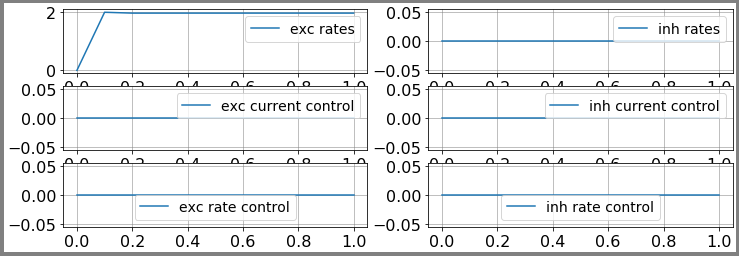

In [391]:
aln = RateModel()

aln.params['duration'] = 1.
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

aln.params.cie = 1.
aln.params.Jie_max = 1.
aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

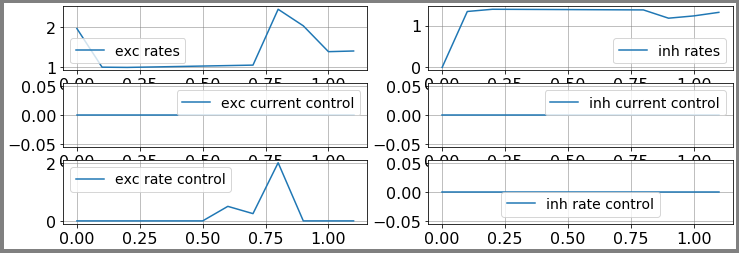

no delay : 
exc rates :  [1.97083733 1.         0.9941953  1.00492135 1.0166168  1.02829073
 1.03995438 1.05159876 2.45511931 2.03915964 1.38964722 1.40657875]
inh rates :  [0.         1.33660544 1.38949113 1.38707414 1.38456766 1.38185785
 1.37920155 1.37657656 1.37398599 1.17617616 1.23048634 1.31583623]


In [526]:
dur = 0.8
dur_pre = 0.3
dur_post = 0.3

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

aln.params.duration = dur + dur_pre

control_ind = [2]
prec_var = [0]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 5.
    min_cntrl = -5.
else:
    max_cntrl = 5.#0.5
    min_cntrl = -5.# 0.5

control0 = aln.getZeroControl()

for j in control_ind:
    #control0[0,j,n_pre + 0] = 1.0 * max_cntrl - 0.0 * min_cntrl
    #control0[0,j,n_pre + 1] = 0.1 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 2] = 0.1 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 3] = 0.05 * max_cntrl #- 0.0 * min_cntrl
    control0[0,j,n_pre + 4] = 0.2 * max_cntrl - 0.2 * min_cntrl
    #control0[0,j,n_pre + 5] = 0.5 * max_cntrl - 0.6 * min_cntrl
    #control0[0,j,n_pre + 6] = 1.0 * max_cntrl - 0.8 * min_cntrl

#control0[0,1,:] = 0.    

setinitvars(high_state_vars)

plotFunc.plot_traces(aln, control0)
print("no delay : ")
print("exc rates : ", aln.rates_exc[0,:])
print("inh rates : ", aln.rates_inh[0,:])

aln.params.duration = dur
target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,n_pre-1:]
target[0,1,:] = aln.rates_inh[0,n_pre-1:]

control1 = aln.getZeroControl()
for k in range(1, control1.shape[2]-1):
    control1[0,j,k] += random.uniform(0., 1.) * 0.1 * max_cntrl

In [527]:
costparams = [1. * 1e0, 1.* 1e-2, 1.* 1e-2]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 1
start_step = 10000.
alg = "A1"
case = "test"

aln.params.duration = dur
#control1 = aln.getZeroControl()
control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
control3 = control0[:,:,n_pre-1:]
control5 = bestControlA_A2[:,:,n_pre-1:-n_post+1]

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, 
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 3.810394756896814

set cost params
RUN  0 , total integrated cost =  0.18164090809874772


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.09218710457655553
RUN  1 , total integrated cost =  0.09218710457655553
Improved over  1  iterations by  49.24760862435311  percent.
Problem in initial value trasfer:  sigmae_f 2.436095767911486 1.016616795909328
Problem in initial value trasfer:  sigmae_f 11.939439670616279 1.9432257675929443
control ind  2
grad =  [-2.01111383  5.46446376 -1.02795383  0.33562374  0.01117216 -0.00895326
  0.00763597  0.00852062  0.        ]
best control =  [0.         0.         0.         0.13809223 0.05924469 0.17464535
 0.25068035 0.19373246 0.27910783 0.16582006 0.14706731 0.
 0.         0.         0.        ]
total runtime =  3.065501300006872


In [464]:
"""
cost precision =  115.5706666455505
cost energy =  0.00017395024122880212
cost sparsity =  0.0017159923320111785
"""

'\ncost precision =  115.5706666455505\ncost energy =  0.00017395024122880212\ncost sparsity =  0.0017159923320111785\n'

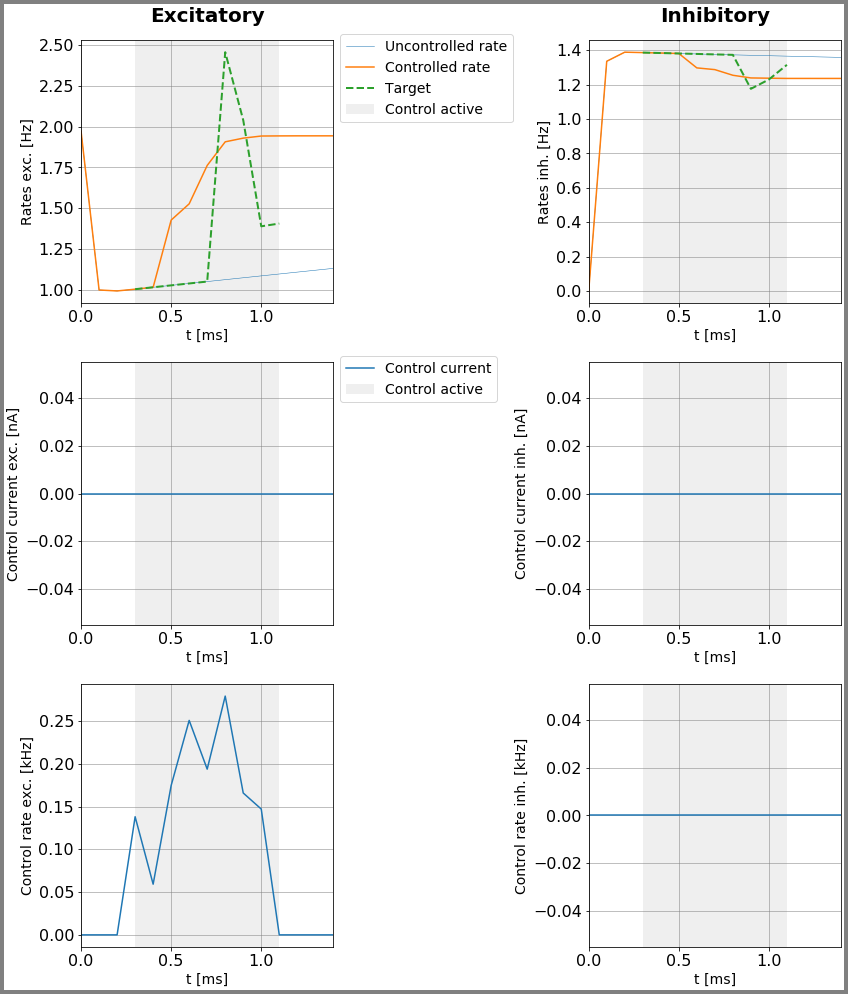

In [528]:
setinitvars(high_state_vars)
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

In [498]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 10
start_step = 0.1
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-12

aln.params.duration = dur
control3 = aln.getZeroControl()
control4 = bestControlA[:,:,n_pre-1:-n_post+1] #* random.uniform(0.001,0.002)

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control4, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

for i in range(1, len(costA_A2)):
    if costA_A2[i-1] < costA_A2[i]:
        print("ERROR ---------------- in index ", i)
        
print(bestControlA_A2[0,control_ind[0], :])

set cost params
RUN  0 , total integrated cost:  0.027857855434837635
RUN  1 , total integrated cost:  0.027857855431755313
RUN  2 , total integrated cost:  0.027857855428840738
RUN  3 , total integrated cost:  0.027857855425944465
RUN  4 , total integrated cost:  0.027857855423069074


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost:  0.02785785540624411
Improved over  10  iterations by  1.0264081140576309e-07  percent.
Problem in initial value trasfer:  sigmae_f 2.683197233851269 1.9758811562702923
Problem in initial value trasfer:  sigmai_f 1.3363447833040825 0.0
Problem in initial value trasfer:  sigmae_f 16.497981860630944 3.7751697471775874
Problem in initial value trasfer:  sigmai_f 1.0173568162191908 0.0
[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.36253413e-03
 5.72535285e-03 5.70121795e-02 4.36944177e-01 2.52270837e-01
 1.99845359e+00 5.87403343e-04 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]


In [ ]:
"""
time, cost =  1 0.014937682629079452
time, cost =  2 0.01582275831986285
time, cost =  3 0.01754859910751686
time, cost =  4 0.017953148854074008
time, cost =  5 0.020738138176752026
time, cost =  6 0.030538319239898998
time, cost =  7 0.03479004824576043
time, cost =  8 0.03479004824576043

exc rate =  [1.97083733 1.97083733 1.98398871 2.09742685 2.19129299 2.01457807
 2.28286872 3.00083276 2.3815665 ]
target =  [ 1.97083733  1.97083733  1.97083733  1.97083733  2.0180278   3.35691485
 50.31767329  1.56595633  1.97668874]
control =  [0.         0.38649298 0.09407846 0.13137126 0.06360423 0.16688287
 0.31305241 0.20619721 0.        ]
"""

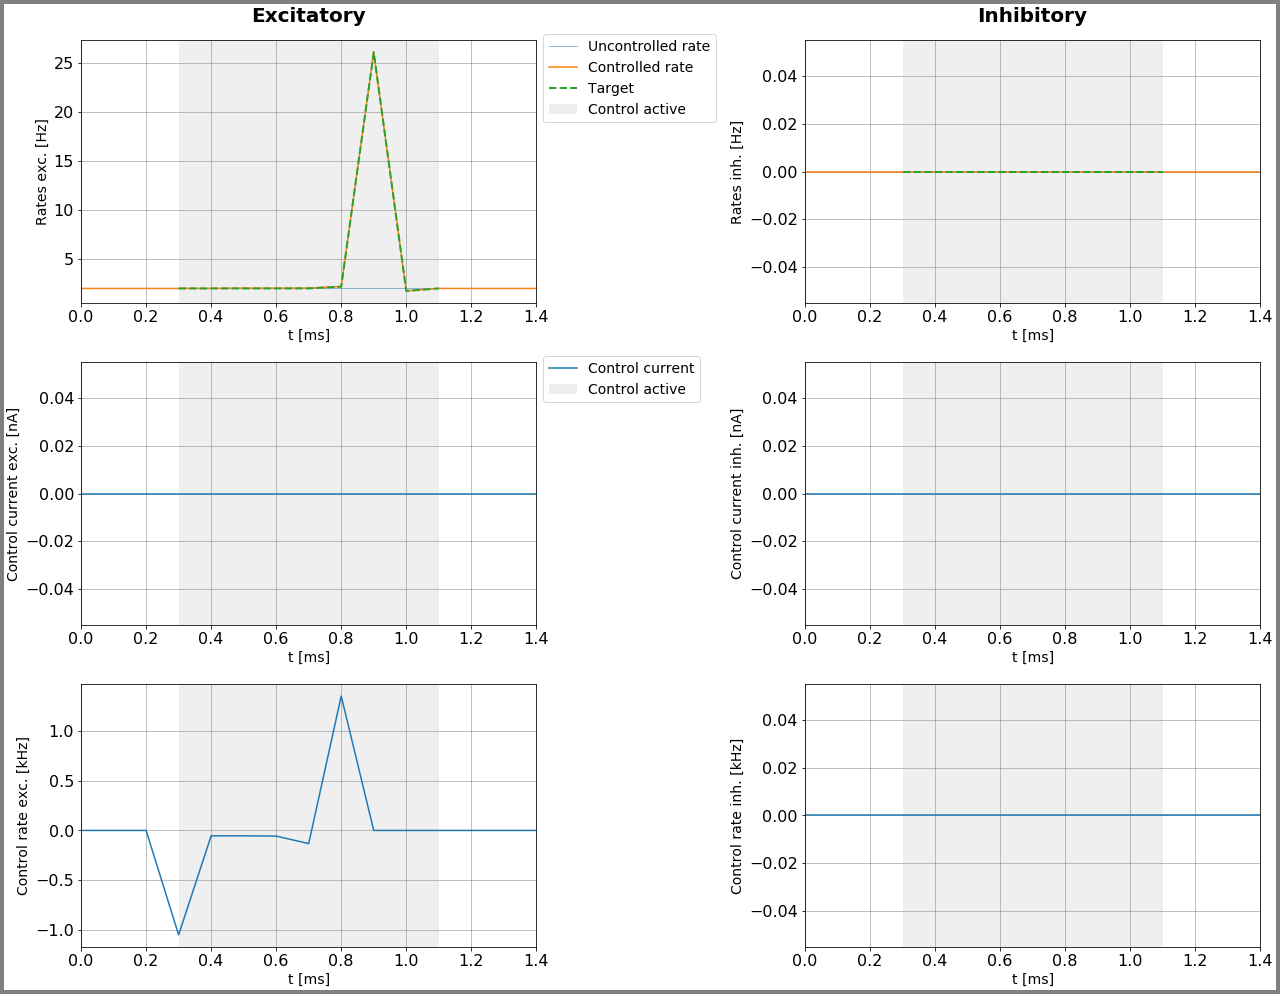

In [472]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

### Test cases

- [] precision only, c0-p0, no delay
- [] precision only, c0-p0, delay
- [] precision only, c0-p1, no delay
- [] precision only, c0-p1, delay
- [] precision only, c1-p1, no delay
- [] precision only, c1-p1, delay
- [] precision only, c1-p0, no delay
- [] precision only, c1-p0, delay
- [] precision only, c2-p0, no delay
- [] precision only, c2-p0, no delay
- [] precision only, c2-p1, delay
- [] precision only, c2-p1, delay

- [] p+e+s, c0-p0, no delay
- [] p+e+s, c0-p0, delay
- [] p+e+s, c0-p1, no delay
- [] p+e+s, c0-p1, delay
- [] p+e+s, c1-p1, no delay
- [] p+e+s, c1-p1, delay
- [] p+e+s, c1-p0, no delay
- [] p+e+s, c1-p0, delay
- [] p+e+s, c2-p0, no delay
- [] p+e+s, c2-p0, no delay
- [] p+e+s, c2-p1, delay
- [] p+e+s, c2-p1, delay

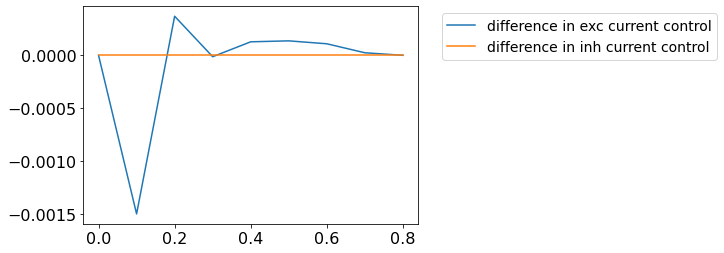

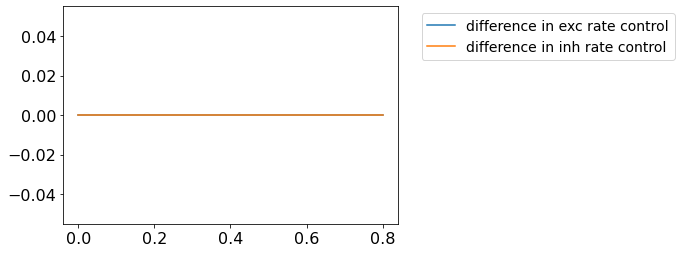

In [114]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.